In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
from pathlib import Path
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Check GPU availability
# print("GPU Available: ", tf.config.list_physical_devices('GPU'))
print("TensorFlow Version: ", tf.__version__)

TensorFlow Version:  2.20.0


Dataset Structure:

ISSUE:
  pothole on road: 867 images
  garbage on street: 180 images
  broken streetlight: 143 images
  overflowing drain: 175 images
  open manhole: 176 images
  damaged public bench: 171 images
  cracked pavement: 130 images
  broken sidewalk: 166 images
  Total issue: 2008 images

NO_ISSUE:
  clean road: 316 images
  street with working lights: 260 images
  well maintained park: 294 images
  clean garbage bin: 266 images
  maintained drainage system: 216 images
  good road condition: 210 images
  clean sidewalk path: 236 images
  organized parking area: 202 images
  Total no_issue: 2000 images

Overall Total: 4008 images


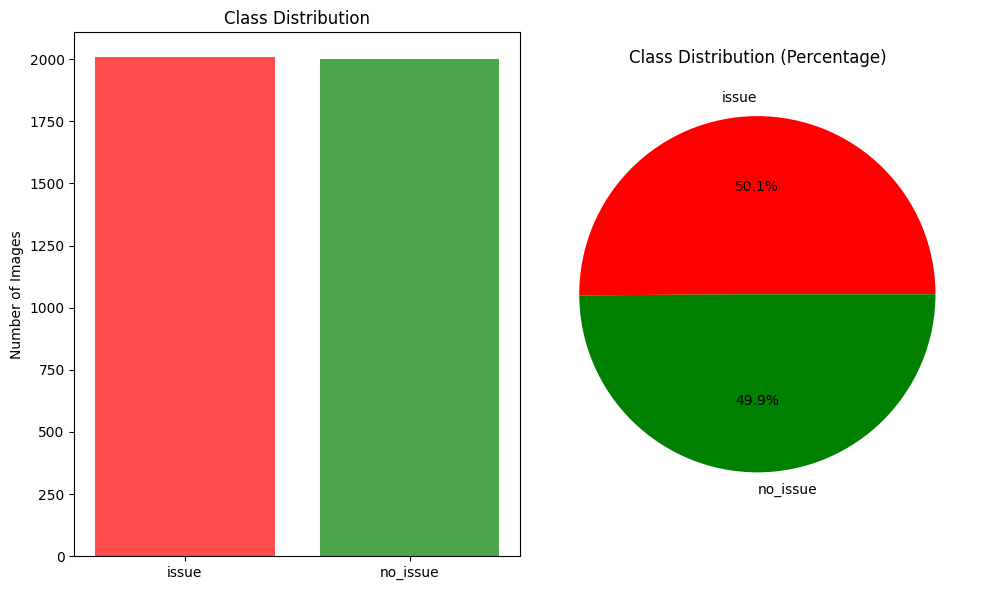

In [3]:
# Define dataset paths
DATASET_PATH = "civic_dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50

# Explore dataset structure
def explore_dataset(dataset_path):
    """Explore and visualize dataset structure"""
    
    print("Dataset Structure:")
    print("=" * 50)
    
    total_images = 0
    class_counts = {}
    
    for class_type in ['issue', 'no_issue']:
        class_path = Path(dataset_path) / class_type
        if class_path.exists():
            class_count = 0
            print(f"\n{class_type.upper()}:")
            
            for subclass in os.listdir(class_path):
                subclass_path = class_path / subclass
                if subclass_path.is_dir():
                    count = len([f for f in os.listdir(subclass_path) 
                               if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    print(f"  {subclass}: {count} images")
                    class_count += count
            
            class_counts[class_type] = class_count
            total_images += class_count
            print(f"  Total {class_type}: {class_count} images")
    
    print(f"\nOverall Total: {total_images} images")
    return class_counts, total_images

# Explore the dataset
class_counts, total_images = explore_dataset(DATASET_PATH)

# Visualize class distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(class_counts.keys(), class_counts.values(), color=['red', 'green'], alpha=0.7)
plt.title('Class Distribution')
plt.ylabel('Number of Images')

plt.subplot(1, 2, 2)
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%', 
        colors=['red', 'green'])
plt.title('Class Distribution (Percentage)')
plt.tight_layout()
plt.show()

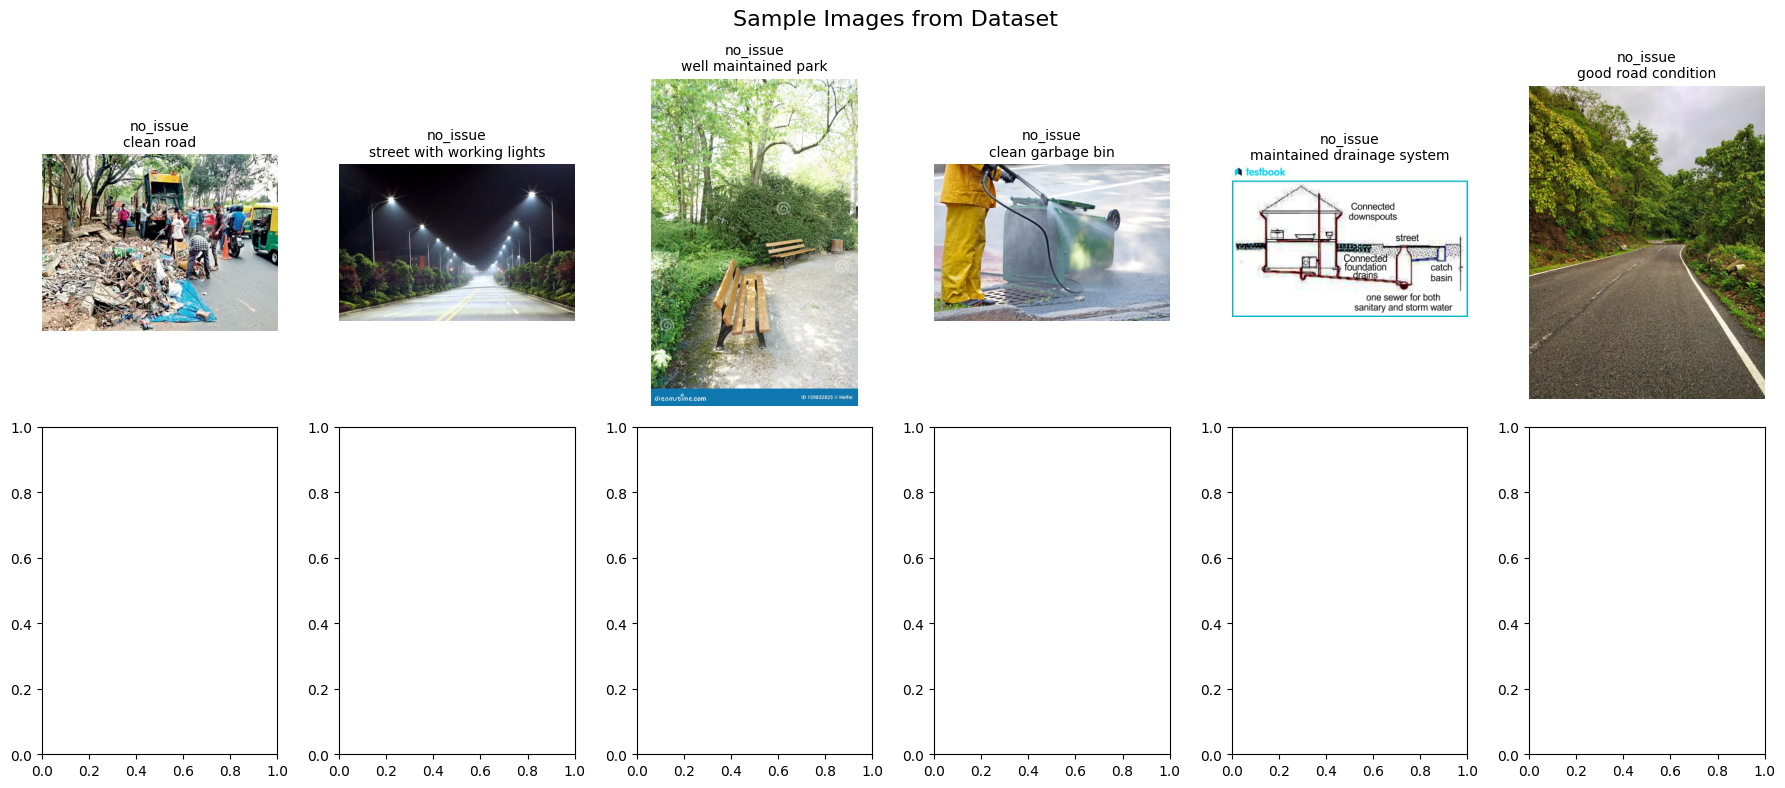

In [4]:
def display_sample_images(dataset_path, samples_per_class=3):
    """Display sample images from each class"""
    
    fig, axes = plt.subplots(2, 6, figsize=(18, 8))
    fig.suptitle('Sample Images from Dataset', fontsize=16)
    
    row = 0
    for class_type in ['issue', 'no_issue']:
        class_path = Path(dataset_path) / class_type
        col = 0
        
        # Get first few subdirectories
        subdirs = [d for d in os.listdir(class_path) if 
                  os.path.isdir(class_path / d)][:6]
        
        for subdir in subdirs:
            subdir_path = class_path / subdir
            images = [f for f in os.listdir(subdir_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if images and col < 6:
                img_path = subdir_path / images[0]
                img = plt.imread(img_path)
                
                axes[row, col].imshow(img)
                axes[row, col].set_title(f'{class_type}\n{subdir}', fontsize=10)
                axes[row, col].axis('off')
                col += 1
    
    plt.tight_layout()
    plt.show()

# Display sample images
display_sample_images(DATASET_PATH)

In [5]:
import os
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----------------------------
# Step 0: Preprocessing - Fix dataset
# ----------------------------

def clean_and_fix_images(dataset_path):
    """Delete corrupted images and convert grayscale/RGBA images to RGB"""
    for root, _, files in os.walk(dataset_path):
        for f in files:
            path = os.path.join(root, f)
            try:
                img = Image.open(path)
                # Convert grayscale or RGBA to RGB
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                    img.save(path)
            except Exception as e:
                print(f"Deleting corrupt image: {path}, error: {e}")
                os.remove(path)

# Run preprocessing
clean_and_fix_images(DATASET_PATH)

# ----------------------------
# Step 1: Create datasets
# ----------------------------
def create_datasets(dataset_path, image_size, batch_size, validation_split=0.2):
    """Create training and validation datasets"""
    
    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=validation_split,
        subset="training",
        seed=42,
        image_size=image_size,
        batch_size=batch_size,
        class_names=['issue', 'no_issue'],
        color_mode='rgb'  # force 3 channels
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=validation_split,
        subset="validation",
        seed=42,
        image_size=image_size,
        batch_size=batch_size,
        class_names=['issue', 'no_issue'],
        color_mode='rgb'  # force 3 channels
    )

    return train_ds, val_ds

# Create datasets
train_dataset, val_dataset = create_datasets(DATASET_PATH, IMAGE_SIZE, BATCH_SIZE)

Found 4008 files belonging to 2 classes.
Using 3207 files for training.
Found 4008 files belonging to 2 classes.
Using 801 files for validation.


In [6]:
# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
])

# Normalization
normalization_layer = layers.Rescaling(1./255)

# Ensure RGB channels
def ensure_rgb(x, y):
    if x.shape[-1] == 1:
        x = tf.image.grayscale_to_rgb(x)
    elif x.shape[-1] == 4:
        x = x[..., :3]
    return x, y

def prepare_dataset(ds, shuffle=False, augment=False):
    """Prepare dataset with normalization and optional augmentation"""
    ds = ds.map(lambda x, y: ensure_rgb(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        ds = ds.shuffle(1000)
    
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

# Prepare datasets
train_ds = prepare_dataset(train_dataset, shuffle=True, augment=True)
val_ds = prepare_dataset(val_dataset)

# ----------------------------
# Step 3: Class info
# ----------------------------
class_names = train_dataset.class_names
print("Class names:", class_names)
num_classes = len(class_names)
print("Number of classes:", num_classes)

Class names: ['issue', 'no_issue']
Number of classes: 2


In [7]:
def create_model(num_classes, input_shape=(224, 224, 3)):
    """Create transfer learning model using EfficientNetB0"""
    
    base_model = None
    model_name = ""
    
    # Try multiple models in order of preference
    models_to_try = [
        {
            'name': 'EfficientNetB0',
            'import_func': lambda: EfficientNetB0,
            'kwargs': {
                'weights': 'imagenet',
                'include_top': False,
                'input_shape': input_shape
            }
        },
        {
            'name': 'MobileNetV2', 
            'import_func': lambda: __import__('tensorflow.keras.applications', fromlist=['MobileNetV2']).MobileNetV2,
            'kwargs': {
                'weights': 'imagenet',
                'include_top': False,
                'input_shape': input_shape,
                'alpha': 1.0
            }
        },
        {
            'name': 'ResNet50V2',
            'import_func': lambda: __import__('tensorflow.keras.applications', fromlist=['ResNet50V2']).ResNet50V2,
            'kwargs': {
                'weights': 'imagenet',
                'include_top': False,
                'input_shape': input_shape
            }
        }
    ]
    
    for model_config in models_to_try:
        try:
            print(f"Trying {model_config['name']}...")
            model_class = model_config['import_func']()
            base_model = model_class(**model_config['kwargs'])
            model_name = model_config['name']
            print(f"✅ Successfully loaded {model_name}")
            break
            
        except Exception as e:
            print(f"❌ {model_config['name']} failed: {str(e)[:100]}...")
            continue
    
    if base_model is None:
        raise RuntimeError("All model attempts failed. Please check your TensorFlow installation.")
    
    # Freeze base model initially
    base_model.trainable = False
    
    print(f"\n🏗️  Model Details:")
    print(f"   • Base Model: {model_name}")
    print(f"   • Input Shape: {base_model.input_shape}")
    print(f"   • Output Shape: {base_model.output_shape}")
    print(f"   • Total Layers: {len(base_model.layers)}")
    
    # Add custom classification head
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax', name='predictions')
    ])
    
    return model, base_model

# Create model
model, base_model = create_model(num_classes)

# Display model architecture
model.summary()

# Compile model
initial_learning_rate = 0.001
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Trying EfficientNetB0...
❌ EfficientNetB0 failed: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3,...
Trying MobileNetV2...
✅ Successfully loaded MobileNetV2

🏗️  Model Details:
   • Base Model: MobileNetV2
   • Input Shape: (None, 224, 224, 3)
   • Output Shape: (None, 7, 7, 1280)
   • Total Layers: 154


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,052,866 (11.65 MB)

 Trainable params: 791,298 (3.02 MB)

 Non-trainable params: 2,261,568 (8.63 MB)

In [8]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    # ModelCheckpoint(
    #     'best_civic_model.h5',
    #     monitor='val_accuracy',
    #     save_best_only=True,
    #     verbose=1
    # )
]

print("Callbacks configured:")
for callback in callbacks:
    print(f"- {callback.__class__.__name__}")


Callbacks configured:
- EarlyStopping
- ReduceLROnPlateau


In [9]:
# Train with frozen base model
initial_epochs = 20
history = model.fit(
    train_ds,
    epochs=initial_epochs,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.5404 - loss: 1.0040 - val_accuracy: 0.6117 - val_loss: 0.7418 - learning_rate: 0.0010
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.5594 - loss: 0.8508 - val_accuracy: 0.6242 - val_loss: 0.8321 - learning_rate: 0.0010
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.5862 - loss: 0.7584 - val_accuracy: 0.7004 - val_loss: 0.5988 - learning_rate: 0.0010
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.5681 - loss: 0.7344 - val_accuracy: 0.6355 - val_loss: 0.8243 - learning_rate: 0.0010
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.5769 - loss: 0.7015 - val_accuracy: 0.7990 - val_loss: 0.4433 - learning_rate: 0.0010
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.5978 - loss: 0.6511 - val_accuracy: 0.8027 - val_loss: 0.4571 - learning_rate: 0.0010
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.5784 - loss: 0.

In [10]:
print("Starting fine-tuning phase...")

# Unfreeze base model for fine-tuning
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) // 2

# Freeze earlier layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with lower learning rate
fine_tune_lr = initial_learning_rate / 10
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=fine_tune_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
fine_tune_epochs = 30
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Starting fine-tuning phase...
Epoch 16/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - accuracy: 0.5647 - loss: 0.6832 - val_accuracy: 0.7428 - val_loss: 0.5252 - learning_rate: 1.0000e-04
Epoch 17/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.6093 - loss: 0.6483 - val_accuracy: 0.7066 - val_loss: 0.5468 - learning_rate: 1.0000e-04
Epoch 18/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.6274 - loss: 0.6271 - val_accuracy: 0.7353 - val_loss: 0.5252 - learning_rate: 1.0000e-04
Epoch 19/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.6221 - loss: 0.6289 - val_accuracy: 0.7553 - val_loss: 0.5151 - learning_rate: 1.0000e-04
Epoch 20/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5973 - loss: 0.6322
Epoch 20: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
101/101 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.6236 - loss: 0.6132 - val_accuracy: 0.7728 - val_loss: 0.4972 - learning_rate: 1.0000e-04
Epoch 21/50
101/101 ━━━━━━━━━

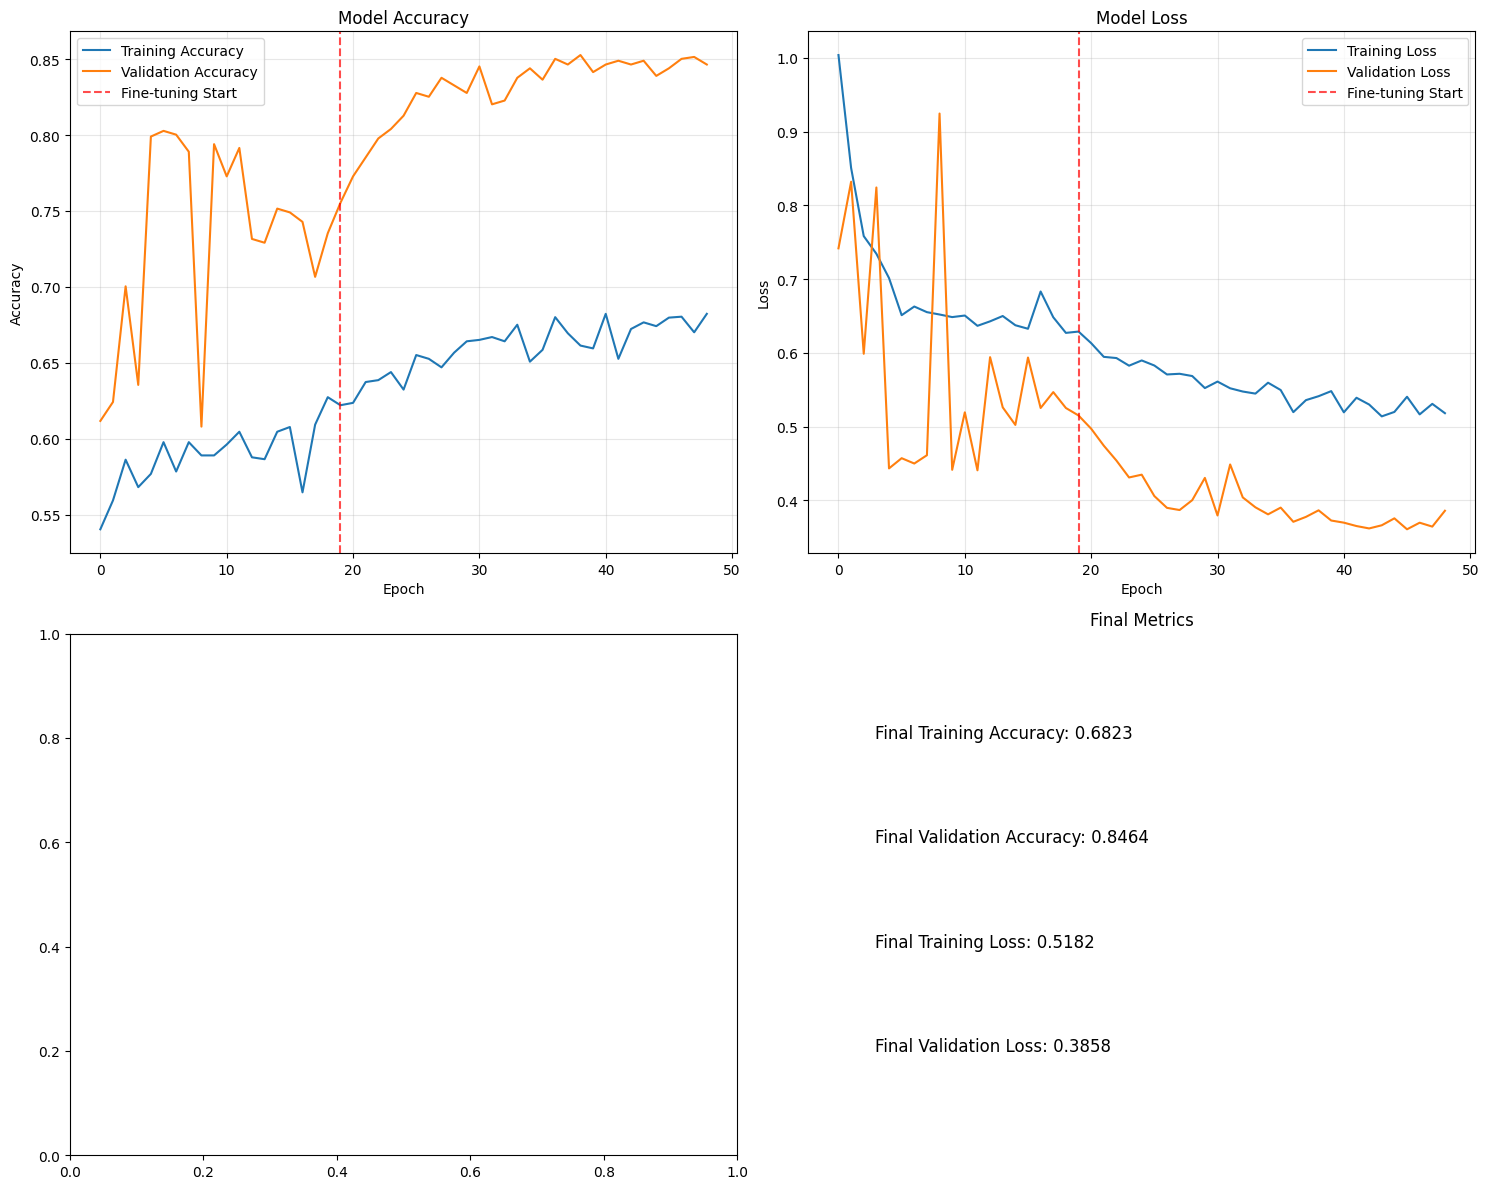

In [11]:
def plot_training_history(history, history_fine, initial_epochs):
    """Plot training and validation metrics"""
    
    # Combine histories
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    if history_fine:
        acc += history_fine.history['accuracy']
        val_acc += history_fine.history['val_accuracy']
        loss += history_fine.history['loss']
        val_loss += history_fine.history['val_loss']
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Accuracy plot
    axes[0, 0].plot(acc, label='Training Accuracy')
    axes[0, 0].plot(val_acc, label='Validation Accuracy')
    axes[0, 0].axvline(x=initial_epochs-1, color='r', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[0, 1].plot(loss, label='Training Loss')
    axes[0, 1].plot(val_loss, label='Validation Loss')
    axes[0, 1].axvline(x=initial_epochs-1, color='r', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Learning rate plot (if available)
    if 'lr' in history.history:
        lr_history = history.history['lr']
        if history_fine and 'lr' in history_fine.history:
            lr_history += history_fine.history['lr']
        
        axes[1, 0].plot(lr_history, label='Learning Rate')
        axes[1, 0].set_title('Learning Rate Schedule')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
        axes[1, 0].set_yscale('log')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Final metrics summary
    final_train_acc = acc[-1]
    final_val_acc = val_acc[-1]
    final_train_loss = loss[-1]
    final_val_loss = val_loss[-1]
    
    axes[1, 1].text(0.1, 0.8, f'Final Training Accuracy: {final_train_acc:.4f}', fontsize=12, transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.1, 0.6, f'Final Validation Accuracy: {final_val_acc:.4f}', fontsize=12, transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.1, 0.4, f'Final Training Loss: {final_train_loss:.4f}', fontsize=12, transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.1, 0.2, f'Final Validation Loss: {final_val_loss:.4f}', fontsize=12, transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Final Metrics')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history, history_fine, initial_epochs)

Evaluating model...

Classification Report:
              precision    recall  f1-score   support

       issue       0.84      0.86      0.85       387
    no_issue       0.87      0.84      0.86       414

    accuracy                           0.85       801
   macro avg       0.85      0.85      0.85       801
weighted avg       0.85      0.85      0.85       801



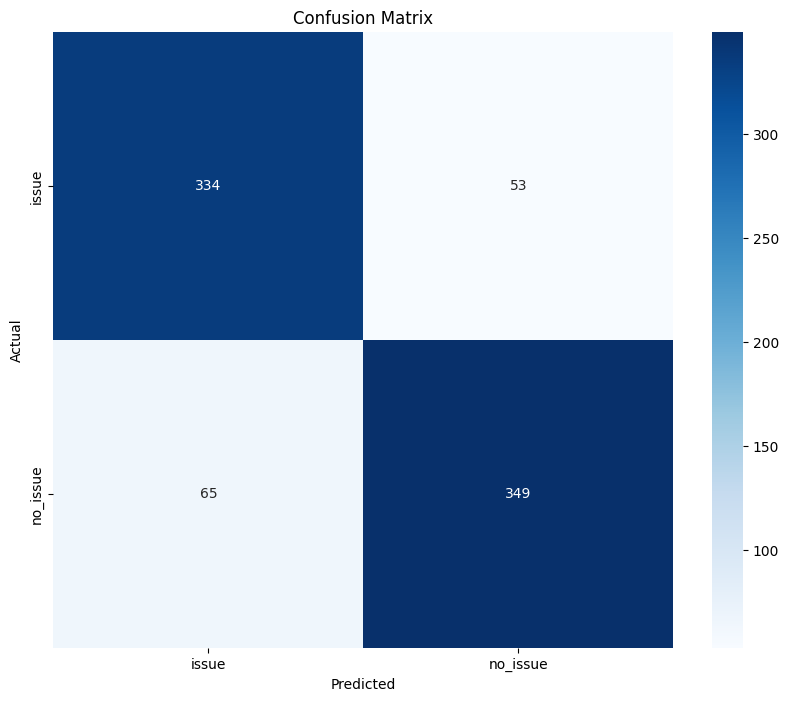


Final Validation Accuracy: 0.8527


In [12]:
def evaluate_model(model, val_ds, class_names):
    """Evaluate model and create confusion matrix"""
    
    print("Evaluating model...")
    
    # Collect predictions
    y_true = []
    y_pred = []
    y_pred_proba = []
    
    for images, labels in val_ds:
        predictions = model.predict(images, verbose=0)
        y_pred_proba.extend(predictions)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(labels.numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_proba = np.array(y_pred_proba)
    
    # Classification report
    print("\nClassification Report:")
    print("=" * 50)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # Calculate and display accuracy
    accuracy = np.sum(y_pred == y_true) / len(y_true)
    print(f"\nFinal Validation Accuracy: {accuracy:.4f}")
    
    return y_true, y_pred, y_pred_proba

# Evaluate the model
y_true, y_pred, y_pred_proba = evaluate_model(model, val_ds, class_names)


In [13]:
def convert_to_tflite(model, save_path='civic_issue_classifier.tflite'):
    """Convert Keras model to TFLite format"""
    
    print("Converting model to TFLite format...")
    
    # Convert to TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # Optimizations
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    # Optional: Use representative dataset for integer quantization
    # converter.representative_dataset = representative_dataset_gen
    # converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # converter.inference_input_type = tf.int8
    # converter.inference_output_type = tf.int8
    
    tflite_model = converter.convert()
    
    # Save the model
    with open(save_path, 'wb') as f:
        f.write(tflite_model)
    
    print(f"TFLite model saved as: {save_path}")
    print(f"Model size: {len(tflite_model) / 1024 / 1024:.2f} MB")
    
    return tflite_model

# Convert model to TFLite
tflite_model = convert_to_tflite(model)

Converting model to TFLite format...
INFO:tensorflow:Assets written to: C:\Users\tanma\AppData\Local\Temp\tmp6b5t2db6\assets


INFO:tensorflow:Assets written to: C:\Users\tanma\AppData\Local\Temp\tmp6b5t2db6\assets


Saved artifact at 'C:\Users\tanma\AppData\Local\Temp\tmp6b5t2db6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_398')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1521919088336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918684880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918684688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918674896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918680656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918685072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918673936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918673744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918673360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521918683152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

In [14]:
def load_and_test_tflite_model(model_path, test_image_path, class_names):
    """Load TFLite model and test on a single image"""
    
    # Load TFLite model
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    # Get input and output tensors
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print("TFLite Model Details:")
    print(f"Input shape: {input_details[0]['shape']}")
    print(f"Output shape: {output_details[0]['shape']}")
    
    # Load and preprocess image
    img = Image.open(test_image_path).convert('RGB')
    img_array = np.array(img.resize((224, 224))) / 255.0
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)
    
    # Set input tensor
    interpreter.set_tensor(input_details[0]['index'], img_array)
    
    # Run inference
    interpreter.invoke()
    
    # Get prediction
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = np.argmax(output_data[0])
    confidence = np.max(output_data[0])
    
    return predicted_class, confidence, output_data[0], img


Testing with Keras model:


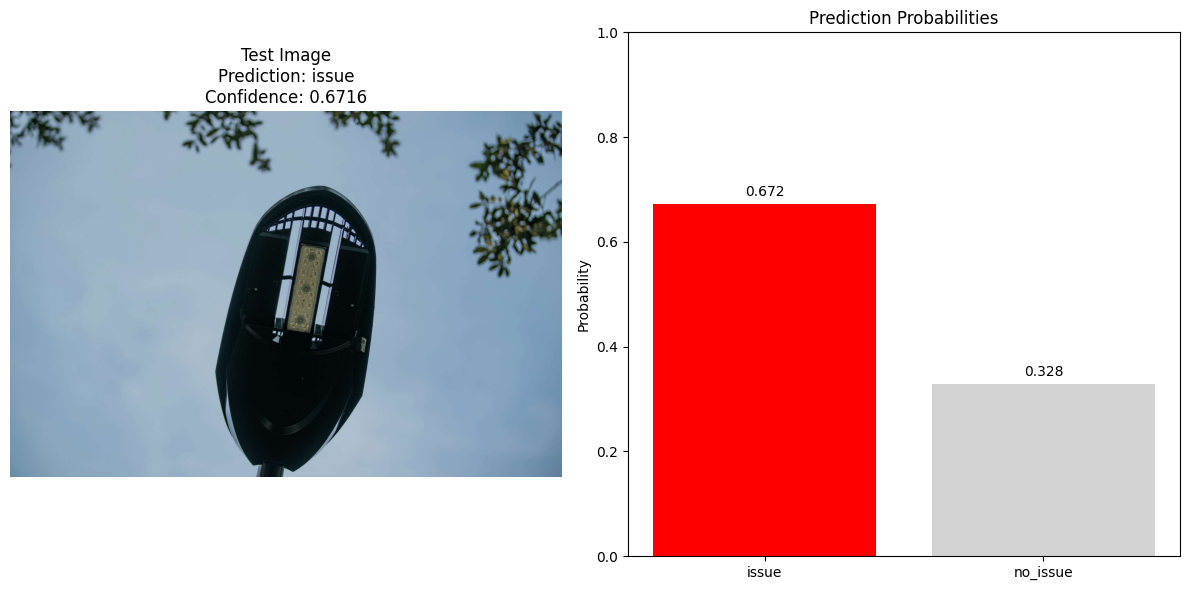

Prediction Results:
- Predicted Class: issue
- Confidence: 0.6716 (67.16%)
- All Probabilities:
  issue: 0.6716 (67.16%)
  no_issue: 0.3284 (32.84%)

Testing with TFLite model:
TFLite Model Details:
Input shape: [  1 224 224   3]
Output shape: [1 2]


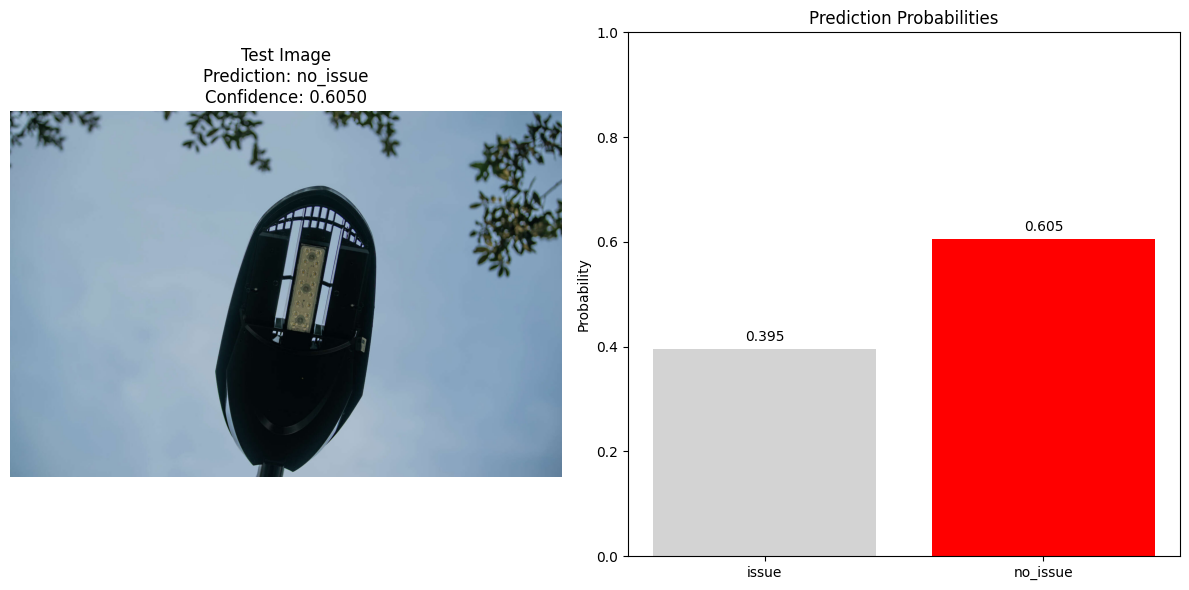

Prediction Results:
- Predicted Class: no_issue
- Confidence: 0.6050 (60.50%)
- All Probabilities:
  issue: 0.3950 (39.50%)
  no_issue: 0.6050 (60.50%)


(np.int64(1),
 np.float32(0.60503864),
 array([0.39496136, 0.60503864], dtype=float32))

In [24]:
def test_single_image(image_path, model_type='keras'):
    """Test prediction on a single image"""
    
    try:
        if model_type == 'keras':
            # Load and preprocess image for Keras model
            img = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
            img_array = tf.keras.utils.img_to_array(img)
            img_array = tf.expand_dims(img_array, 0) / 255.0
            
            # Make prediction
            predictions = model.predict(img_array, verbose=0)
            predicted_class = np.argmax(predictions[0])
            confidence = np.max(predictions[0])
            all_probs = predictions[0]
            
        else:  # TFLite model
            predicted_class, confidence, all_probs, img = load_and_test_tflite_model(
                'civic_issue_classifier.tflite', image_path, class_names)
        
        # Display results
        plt.figure(figsize=(12, 6))
        
        # Show image
        plt.subplot(1, 2, 1)
        if model_type == 'keras':
            plt.imshow(tf.keras.utils.load_img(image_path))
        else:
            plt.imshow(img)
        plt.title(f'Test Image\nPrediction: {class_names[predicted_class]}\nConfidence: {confidence:.4f}')
        plt.axis('off')
        
        # Show probability distribution
        plt.subplot(1, 2, 2)
        bars = plt.bar(class_names, all_probs, color=['red' if i == predicted_class else 'lightgray' for i in range(len(class_names))])
        plt.title('Prediction Probabilities')
        plt.ylabel('Probability')
        plt.ylim(0, 1)
        
        # Add value labels on bars
        for bar, prob in zip(bars, all_probs):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{prob:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed results
        print(f"Prediction Results:")
        print(f"- Predicted Class: {class_names[predicted_class]}")
        print(f"- Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
        print(f"- All Probabilities:")
        for i, (class_name, prob) in enumerate(zip(class_names, all_probs)):
            print(f"  {class_name}: {prob:.4f} ({prob*100:.2f}%)")
        
        return predicted_class, confidence, all_probs
        
    except Exception as e:
        print(f"Error testing image: {str(e)}")
        return None, None, None

# Example usage - Replace with actual image path
print("Testing with Keras model:")
print("=" * 50)
test_single_image("broken3.jpg", model_type='keras')

print("\nTesting with TFLite model:")
print("=" * 50)
test_single_image("broken3.jpg", model_type='tflite')

Testing random images from dataset...


<Figure size 2000x1500 with 0 Axes>

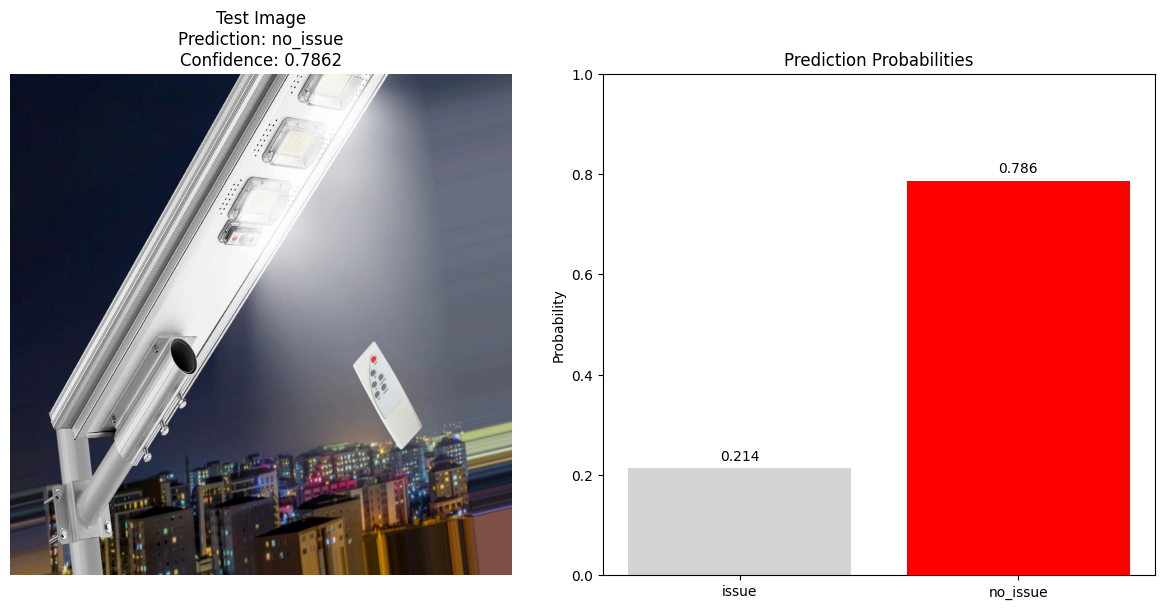

Prediction Results:
- Predicted Class: no_issue
- Confidence: 0.7862 (78.62%)
- All Probabilities:
  issue: 0.2138 (21.38%)
  no_issue: 0.7862 (78.62%)


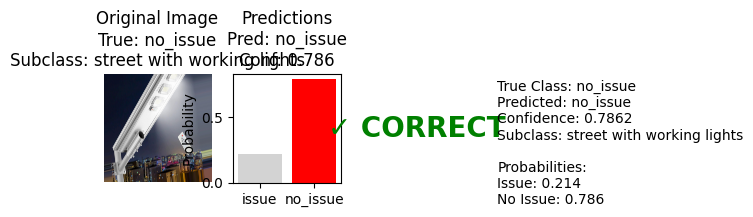

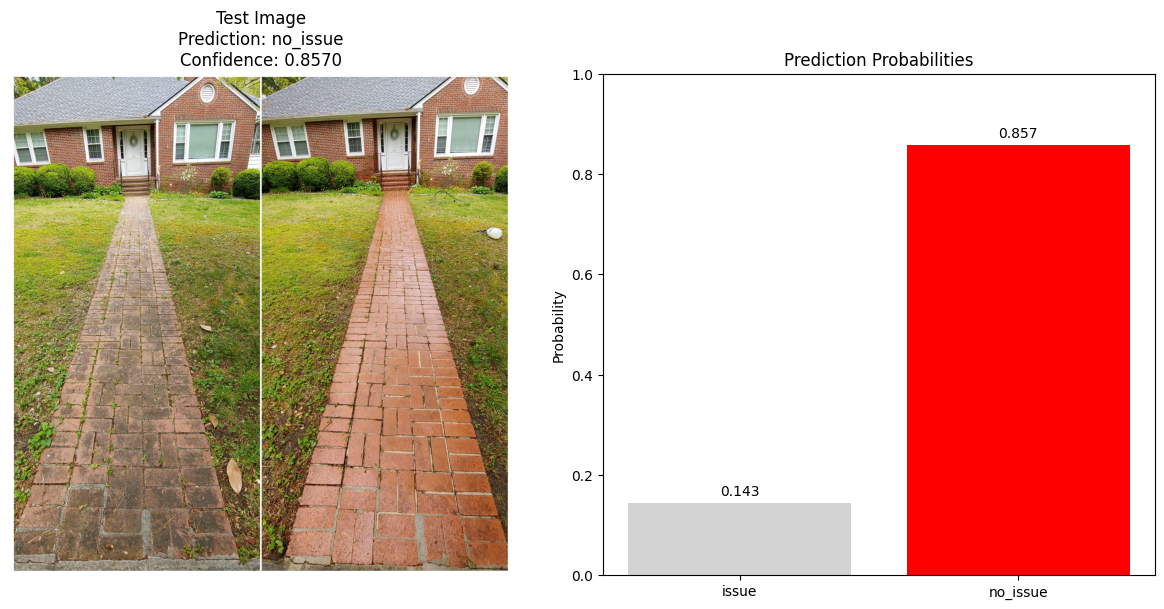

Prediction Results:
- Predicted Class: no_issue
- Confidence: 0.8570 (85.70%)
- All Probabilities:
  issue: 0.1430 (14.30%)
  no_issue: 0.8570 (85.70%)


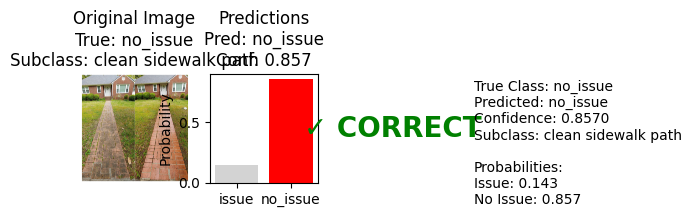

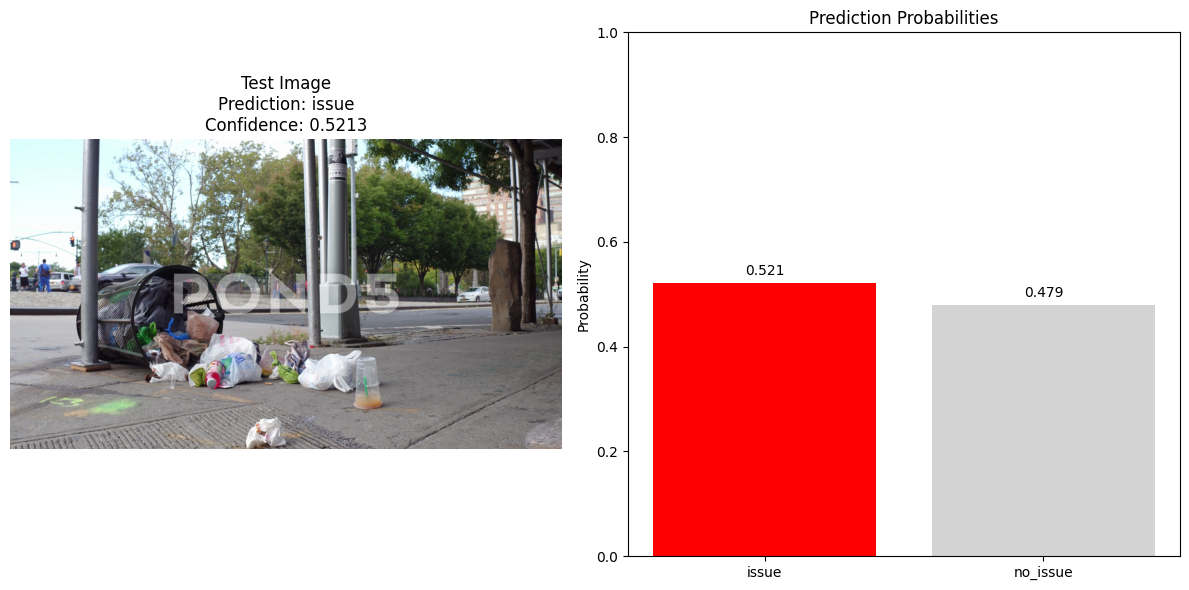

Prediction Results:
- Predicted Class: issue
- Confidence: 0.5213 (52.13%)
- All Probabilities:
  issue: 0.5213 (52.13%)
  no_issue: 0.4787 (47.87%)


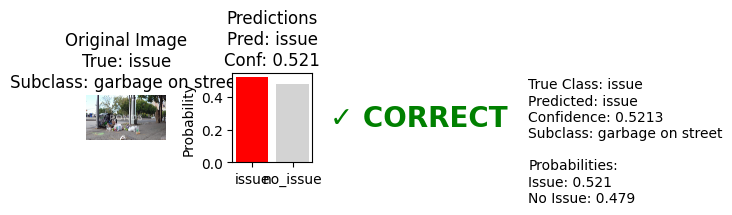


CIVIC ISSUE CLASSIFICATION MODEL - COMPLETE!
✓ Model trained with transfer learning (EfficientNetB0)
✓ Data augmentation applied
✓ Best model saved as 'best_civic_model.h5'
✓ TFLite model saved as 'civic_issue_classifier.tflite'
✓ Training history and evaluation plots generated
✓ Model ready for deployment and testing


In [16]:
def test_random_images_from_dataset(dataset_path, num_samples=4):
    """Test random images from the dataset"""
    
    print("Testing random images from dataset...")
    
    # Collect all image paths
    all_images = []
    for class_type in ['issue', 'no_issue']:
        class_path = Path(dataset_path) / class_type
        for subclass in os.listdir(class_path):
            subclass_path = class_path / subclass
            if subclass_path.is_dir():
                for img_file in os.listdir(subclass_path):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        all_images.append((subclass_path / img_file, class_type, subclass))
    
    # Select random samples
    random_samples = np.random.choice(len(all_images), num_samples, replace=False)
    
    plt.figure(figsize=(20, 5*num_samples))
    
    for i, idx in enumerate(random_samples):
        img_path, true_class, subclass = all_images[idx]
        
        # Test with Keras model
        predicted_class, confidence, all_probs = test_single_image(str(img_path), model_type='keras')
        
        if predicted_class is not None:
            # Display image and results
            plt.subplot(num_samples, 4, i*4 + 1)
            img = plt.imread(img_path)
            plt.imshow(img)
            plt.title(f'Original Image\nTrue: {true_class}\nSubclass: {subclass}')
            plt.axis('off')
            
            plt.subplot(num_samples, 4, i*4 + 2)
            plt.bar(class_names, all_probs, color=['red' if j == predicted_class else 'lightgray' for j in range(len(class_names))])
            plt.title(f'Predictions\nPred: {class_names[predicted_class]}\nConf: {confidence:.3f}')
            plt.ylabel('Probability')
            
            # Show if prediction is correct
            is_correct = class_names[predicted_class] == true_class
            plt.subplot(num_samples, 4, i*4 + 3)
            plt.text(0.5, 0.5, f"{'✓ CORRECT' if is_correct else '✗ INCORRECT'}", 
                    ha='center', va='center', fontsize=20, 
                    color='green' if is_correct else 'red', weight='bold')
            plt.xlim(0, 1)
            plt.ylim(0, 1)
            plt.axis('off')
            
            plt.subplot(num_samples, 4, i*4 + 4)
            details_text = f"""
True Class: {true_class}
Predicted: {class_names[predicted_class]}
Confidence: {confidence:.4f}
Subclass: {subclass}

Probabilities:
Issue: {all_probs[0]:.3f}
No Issue: {all_probs[1]:.3f}
            """
            plt.text(0.05, 0.95, details_text.strip(), ha='left', va='top', 
                    fontsize=10, transform=plt.gca().transAxes)
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Test random images from dataset
test_random_images_from_dataset(DATASET_PATH, num_samples=3)

print("\n" + "="*80)
print("CIVIC ISSUE CLASSIFICATION MODEL - COMPLETE!")
print("="*80)
print("✓ Model trained with transfer learning (EfficientNetB0)")
print("✓ Data augmentation applied")
print("✓ Best model saved as 'best_civic_model.h5'")
print("✓ TFLite model saved as 'civic_issue_classifier.tflite'")
print("✓ Training history and evaluation plots generated")
print("✓ Model ready for deployment and testing")
print("="*80)


In [17]:
def print_model_summary():
    """Print comprehensive model summary"""
    
    print("\n📊 MODEL PERFORMANCE SUMMARY")
    print("="*60)
    
    # Model architecture info
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    
    print(f"🏗️  MODEL ARCHITECTURE:")
    print(f"   • Base Model: EfficientNetB0 (ImageNet pretrained)")
    print(f"   • Input Shape: {IMAGE_SIZE + (3,)}")
    print(f"   • Total Parameters: {total_params:,}")
    print(f"   • Trainable Parameters: {trainable_params:,}")
    print(f"   • Non-trainable Parameters: {non_trainable_params:,}")
    
    print(f"\n📁 DATASET INFO:")
    print(f"   • Total Images: {total_images}")
    print(f"   • Classes: {class_names}")
    print(f"   • Training Split: 80%")
    print(f"   • Validation Split: 20%")
    
    print(f"\n⚙️  TRAINING CONFIGURATION:")
    print(f"   • Initial Epochs: {initial_epochs}")
    print(f"   • Fine-tuning Epochs: {fine_tune_epochs}")
    print(f"   • Total Epochs: {total_epochs}")
    print(f"   • Batch Size: {BATCH_SIZE}")
    print(f"   • Image Size: {IMAGE_SIZE}")
    print(f"   • Initial Learning Rate: {initial_learning_rate}")
    print(f"   • Fine-tuning Learning Rate: {fine_tune_lr}")
    
    print(f"\n🔧 DATA AUGMENTATION:")
    print(f"   • Random Horizontal Flip")
    print(f"   • Random Rotation (±10%)")
    print(f"   • Random Zoom (±20%)")
    print(f"   • Random Contrast (±10%)")
    print(f"   • Random Brightness (±10%)")
    
    print(f"\n📱 MODEL DEPLOYMENT:")
    print(f"   • Keras Model: best_civic_model.h5")
    print(f"   • TFLite Model: civic_issue_classifier.tflite")
    print(f"   • TFLite Size: {len(tflite_model) / 1024 / 1024:.2f} MB")
    
    print("="*60)

# Print model summary
print_model_summary()


📊 MODEL PERFORMANCE SUMMARY
🏗️  MODEL ARCHITECTURE:
   • Base Model: EfficientNetB0 (ImageNet pretrained)
   • Input Shape: (224, 224, 3)
   • Total Parameters: 3,052,866
   • Trainable Parameters: 2,854,786
   • Non-trainable Parameters: 198,080

📁 DATASET INFO:
   • Total Images: 4008
   • Classes: ['issue', 'no_issue']
   • Training Split: 80%
   • Validation Split: 20%

⚙️  TRAINING CONFIGURATION:
   • Initial Epochs: 20
   • Fine-tuning Epochs: 30
   • Total Epochs: 50
   • Batch Size: 32
   • Image Size: (224, 224)
   • Initial Learning Rate: 0.001
   • Fine-tuning Learning Rate: 0.0001

🔧 DATA AUGMENTATION:
   • Random Horizontal Flip
   • Random Rotation (±10%)
   • Random Zoom (±20%)
   • Random Contrast (±10%)
   • Random Brightness (±10%)

📱 MODEL DEPLOYMENT:
   • Keras Model: best_civic_model.h5
   • TFLite Model: civic_issue_classifier.tflite
   • TFLite Size: 3.15 MB


In [18]:
import json
from datetime import datetime

def save_model_metadata():
    """Save model training metadata"""
    
    metadata = {
        "model_info": {
            "name": "Civic Issue Classifier",
            "base_model": "EfficientNetB0",
            "framework": "TensorFlow/Keras",
            "version": tf.__version__,
            "created_date": datetime.now().isoformat(),
        },
        "dataset_info": {
            "total_images": int(total_images),
            "classes": class_names,
            "class_distribution": {k: int(v) for k, v in class_counts.items()},
        },
        "training_config": {
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "initial_epochs": initial_epochs,
            "fine_tune_epochs": fine_tune_epochs,
            "total_epochs": total_epochs,
            "initial_learning_rate": initial_learning_rate,
            "fine_tune_learning_rate": fine_tune_lr,
        },
        "model_performance": {
            "final_train_accuracy": float(history_fine.history['accuracy'][-1]) if history_fine else float(history.history['accuracy'][-1]),
            "final_val_accuracy": float(history_fine.history['val_accuracy'][-1]) if history_fine else float(history.history['val_accuracy'][-1]),
            "final_train_loss": float(history_fine.history['loss'][-1]) if history_fine else float(history.history['loss'][-1]),
            "final_val_loss": float(history_fine.history['val_loss'][-1]) if history_fine else float(history.history['val_loss'][-1]),
        },
        "files_generated": {
            "keras_model": "best_civic_model.h5",
            "tflite_model": "civic_issue_classifier.tflite",
            "metadata": "model_metadata.json"
        }
    }
    
    # Save metadata
    with open('model_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print("📄 Model metadata saved as 'model_metadata.json'")
    return metadata

# Save metadata
model_metadata = save_model_metadata()

📄 Model metadata saved as 'model_metadata.json'


In [19]:
# ============================================================================
# CELL 18: Deployment Ready Functions
# ============================================================================

class CivicIssueClassifier:
    """
    Ready-to-use Civic Issue Classifier class for deployment
    """
    
    def __init__(self, model_path=None, use_tflite=False):
        """
        Initialize the classifier
        
        Args:
            model_path (str): Path to model file
            use_tflite (bool): Whether to use TFLite model
        """
        self.use_tflite = use_tflite
        self.class_names = ['issue', 'no_issue']
        self.input_size = (224, 224)
        
        if use_tflite:
            self.model_path = model_path or 'civic_issue_classifier.tflite'
            self.interpreter = tf.lite.Interpreter(model_path=self.model_path)
            self.interpreter.allocate_tensors()
            self.input_details = self.interpreter.get_input_details()
            self.output_details = self.interpreter.get_output_details()
        else:
            self.model_path = model_path or 'best_civic_model.h5'
            self.model = keras.models.load_model(self.model_path)
    
    def preprocess_image(self, image_path_or_array):
        """
        Preprocess image for prediction
        
        Args:
            image_path_or_array: Path to image file or numpy array
            
        Returns:
            Preprocessed image array
        """
        if isinstance(image_path_or_array, str):
            # Load from file path
            img = Image.open(image_path_or_array).convert('RGB')
        else:
            # Use numpy array directly
            img = Image.fromarray(image_path_or_array).convert('RGB')
        
        # Resize and normalize
        img = img.resize(self.input_size)
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0).astype(np.float32)
        
        return img_array
    
    def predict(self, image_path_or_array, return_probabilities=True):
        """
        Make prediction on image
        
        Args:
            image_path_or_array: Path to image file or numpy array
            return_probabilities (bool): Whether to return class probabilities
            
        Returns:
            dict: Prediction results
        """
        # Preprocess image
        img_array = self.preprocess_image(image_path_or_array)
        
        if self.use_tflite:
            # TFLite prediction
            self.interpreter.set_tensor(self.input_details[0]['index'], img_array)
            self.interpreter.invoke()
            predictions = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
        else:
            # Keras prediction
            predictions = self.model.predict(img_array, verbose=0)[0]
        
        # Get results
        predicted_class_idx = np.argmax(predictions)
        predicted_class = self.class_names[predicted_class_idx]
        confidence = float(np.max(predictions))
        
        result = {
            'predicted_class': predicted_class,
            'confidence': confidence,
            'is_issue': predicted_class == 'issue'
        }
        
        if return_probabilities:
            result['probabilities'] = {
                class_name: float(prob) 
                for class_name, prob in zip(self.class_names, predictions)
            }
        
        return result
    
    def predict_batch(self, image_paths, return_probabilities=True):
        """
        Make predictions on multiple images
        
        Args:
            image_paths (list): List of image paths
            return_probabilities (bool): Whether to return class probabilities
            
        Returns:
            list: List of prediction results
        """
        results = []
        for image_path in image_paths:
            try:
                result = self.predict(image_path, return_probabilities)
                result['image_path'] = image_path
                results.append(result)
            except Exception as e:
                results.append({
                    'image_path': image_path,
                    'error': str(e),
                    'predicted_class': None,
                    'confidence': 0.0,
                    'is_issue': None
                })
        
        return results
